# 🛒 Brazilian E-Commerce (Olist) — Full Structured EDA

**Dataset:** Brazilian E-Commerce Public Dataset by Olist
**Environment:** Google Colab
**Data source:** Google Drive

This notebook performs a complete, structured Exploratory Data Analysis (EDA) covering:

1. Import Libraries
2. Connect Dataset (Google Drive)
3. Load All CSV Files
4. Dataset Overview
5. Data Quality Analysis
6. Statistical Analysis
7. Univariate Analysis
8. Bivariate Analysis
9. Multivariate Analysis
10. Outlier Detection
11. Date-Time Analysis
12. Business Insights
13. Feature Engineering Preparation
14. Final EDA Summary

> ⚠️ **Before running:** Upload the Olist dataset CSVs to a folder in your Google Drive (e.g. `MyDrive/olist_dataset/`) and update `DATA_PATH` in Section 2.


## 1. Import Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display / plotting settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


## 2. Connect Dataset (Google Drive)

Mount Google Drive and set the folder path where the Olist CSV files live.
Update `DATA_PATH` below to match your Drive folder structure.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Set this to the folder in your Google Drive containing the 9 Olist CSV files.
# If unsure of the exact name, the auto-search below will try a few common variants.
DATA_PATH = '/content/drive/MyDrive/olist_dataset'

import os

def find_data_path(base='/content/drive/MyDrive'):
    candidates = ['olist_dataset', 'olist_datase', 'olist', 'olist_data', 'Olist Dataset']
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.exists(p) and any(f.endswith('.csv') for f in os.listdir(p)):
            return p
    return None

if not os.path.exists(DATA_PATH):
    found = find_data_path()
    if found:
        print(f"DATA_PATH not found, but auto-detected: {found}")
        DATA_PATH = found

if os.path.exists(DATA_PATH):
    print("Path found. Files inside:")
    for f in sorted(os.listdir(DATA_PATH)):
        print(" -", f)
else:
    print("Path not found. Please edit DATA_PATH above to match your Drive folder.")


DATA_PATH not found, but auto-detected: /content/drive/MyDrive/olist_datase
Path found. Files inside:
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_orders_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


## 3. Load All CSV Files

Standard Olist filenames are used below with automatic fallbacks in case your files
are named slightly differently (e.g. without the `olist_` prefix).


In [5]:
def smart_read_csv(path, filenames):
    """Try a list of possible filenames and return the first that loads successfully."""
    for name in filenames:
        full_path = os.path.join(path, name)
        if os.path.exists(full_path):
            df = pd.read_csv(full_path)
            print(f"✅ Loaded {name}  -> shape {df.shape}")
            return df
    print(f"⚠️ None of these files found: {filenames}")
    return pd.DataFrame()

customers    = smart_read_csv(DATA_PATH, ['olist_customers_dataset.csv', 'customers.csv'])
orders       = smart_read_csv(DATA_PATH, ['olist_orders_dataset.csv', 'orders.csv'])
products     = smart_read_csv(DATA_PATH, ['olist_products_dataset.csv', 'products.csv'])
sellers      = smart_read_csv(DATA_PATH, ['olist_sellers_dataset.csv', 'sellers.csv'])
payments     = smart_read_csv(DATA_PATH, ['olist_order_payments_dataset.csv', 'payments.csv'])
reviews      = smart_read_csv(DATA_PATH, ['olist_order_reviews_dataset.csv', 'reviews.csv'])
items        = smart_read_csv(DATA_PATH, ['olist_order_items_dataset.csv', 'items.csv'])
geolocation  = smart_read_csv(DATA_PATH, ['olist_geolocation_dataset.csv', 'geolocation.csv'])
category_translation = smart_read_csv(DATA_PATH, ['product_category_name_translation.csv'])

datasets = {
    'customers': customers, 'orders': orders, 'products': products,
    'sellers': sellers, 'payments': payments, 'reviews': reviews,
    'items': items, 'geolocation': geolocation
}


✅ Loaded olist_customers_dataset.csv  -> shape (99441, 5)
✅ Loaded olist_orders_dataset.csv  -> shape (99441, 8)
✅ Loaded olist_products_dataset.csv  -> shape (32951, 9)
✅ Loaded olist_sellers_dataset.csv  -> shape (3095, 4)
✅ Loaded olist_order_payments_dataset.csv  -> shape (103886, 5)
✅ Loaded olist_order_reviews_dataset.csv  -> shape (99224, 7)
✅ Loaded olist_order_items_dataset.csv  -> shape (112650, 7)
✅ Loaded olist_geolocation_dataset.csv  -> shape (1000163, 5)
✅ Loaded product_category_name_translation.csv  -> shape (71, 2)


In [6]:
# Translate product category names to English if translation table is available
if not category_translation.empty and not products.empty and 'product_category_name' in products.columns:
    products = products.merge(category_translation, on='product_category_name', how='left')
    print("\u2705 Product categories translated to English where available.")

    # Check translation coverage
    unmatched = products['product_category_name_english'].isna().sum()
    total_with_category = products['product_category_name'].notna().sum()
    print(f"\u26a0\ufe0f Products with a category but NO English translation match: {unmatched} "
          f"(out of {total_with_category} products with a known category)")


✅ Product categories translated to English where available.
⚠️ Products with a category but NO English translation match: 623 (out of 32341 products with a known category)


## 4. Dataset Overview

In [7]:
for name, df in datasets.items():
    print(f"{'='*60}")
    print(f"📦 {name.upper()}  |  Shape: {df.shape}")
    print(f"{'='*60}")


📦 CUSTOMERS  |  Shape: (99441, 5)
📦 ORDERS  |  Shape: (99441, 8)
📦 PRODUCTS  |  Shape: (32951, 9)
📦 SELLERS  |  Shape: (3095, 4)
📦 PAYMENTS  |  Shape: (103886, 5)
📦 REVIEWS  |  Shape: (99224, 7)
📦 ITEMS  |  Shape: (112650, 7)
📦 GEOLOCATION  |  Shape: (1000163, 5)


In [8]:
for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n📋 HEAD — {name}")
    display(df.head())



📋 HEAD — customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



📋 HEAD — orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



📋 HEAD — products


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



📋 HEAD — items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



📋 HEAD — geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


In [9]:
for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n📋 TAIL — {name}")
    display(df.tail())



📋 TAIL — customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP



📋 TAIL — orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00



📋 TAIL — products


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49



📋 TAIL — items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79



📋 TAIL — geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
1000158,99950,-28.07,-52.01,tapejara,RS
1000159,99900,-27.88,-52.22,getulio vargas,RS
1000160,99950,-28.07,-52.01,tapejara,RS
1000161,99980,-28.39,-51.85,david canabarro,RS
1000162,99950,-28.07,-52.02,tapejara,RS


In [10]:
for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n🧱 COLUMNS — {name}")
    print(list(df.columns))



🧱 COLUMNS — customers
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

🧱 COLUMNS — orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

🧱 COLUMNS — products
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

🧱 COLUMNS — sellers
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

🧱 COLUMNS — payments
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

🧱 COLUMNS — reviews
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

🧱 COLUMNS — items
['order_id', 'order_item_id', 'product_id', 'seller_id', 

In [11]:
for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n🔠 DATA TYPES — {name}")
    print(df.dtypes)



🔠 DATA TYPES — customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

🔠 DATA TYPES — orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

🔠 DATA TYPES — products
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

🔠 DATA TYPES — sellers
seller_id              

,dataset,rows,columns,memory_MB
7,geolocation,1000163,5,129.38
1,orders,99441,8,52.94
5,reviews,99224,7,39.12
6,items,112650,7,35.99
0,customers,99441,5,26.59
4,payments,103886,5,16.23
2,products,32951,9,6.30
3,sellers,3095,4,0.59


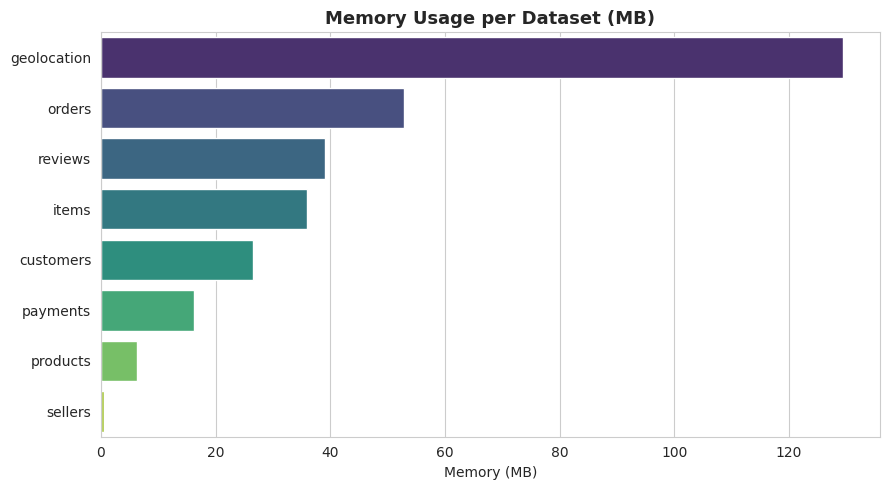

In [12]:
memory_summary = []
for name, df in datasets.items():
    if df.empty:
        continue
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    memory_summary.append({'dataset': name, 'rows': df.shape[0], 'columns': df.shape[1], 'memory_MB': round(mem_mb, 2)})

memory_df = pd.DataFrame(memory_summary).sort_values('memory_MB', ascending=False)
display(memory_df)

plt.figure(figsize=(9,5))
sns.barplot(data=memory_df, x='memory_MB', y='dataset', palette='viridis')
plt.title('Memory Usage per Dataset (MB)')
plt.xlabel('Memory (MB)')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Data Quality Analysis

In [13]:
def missing_value_report(df, name):
    if df.empty:
        return pd.DataFrame()
    missing = df.isnull().sum()
    pct = (missing / len(df)) * 100
    report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct.round(2)})
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    return report

for name, df in datasets.items():
    if df.empty:
        continue
    rep = missing_value_report(df, name)
    print(f"\n🕳️ MISSING VALUES — {name}")
    if rep.empty:
        print("No missing values ✅")
    else:
        display(rep)



🕳️ MISSING VALUES — customers
No missing values ✅

🕳️ MISSING VALUES — orders


,missing_count,missing_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



🕳️ MISSING VALUES — products


,missing_count,missing_pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



🕳️ MISSING VALUES — sellers
No missing values ✅

🕳️ MISSING VALUES — payments
No missing values ✅

🕳️ MISSING VALUES — reviews


,missing_count,missing_pct
review_comment_title,87656,88.34
review_comment_message,58247,58.70



🕳️ MISSING VALUES — items
No missing values ✅

🕳️ MISSING VALUES — geolocation
No missing values ✅


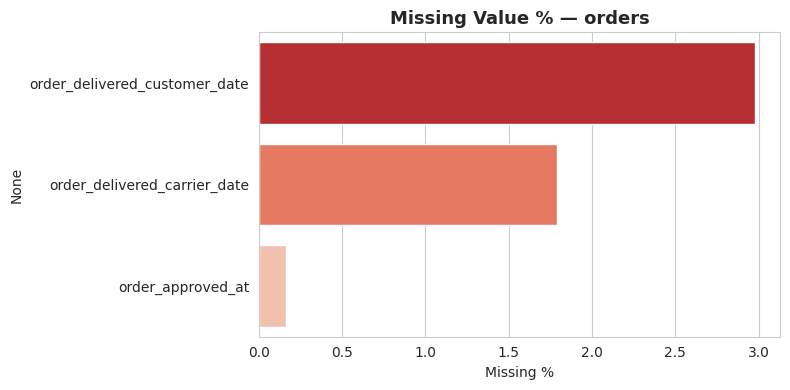

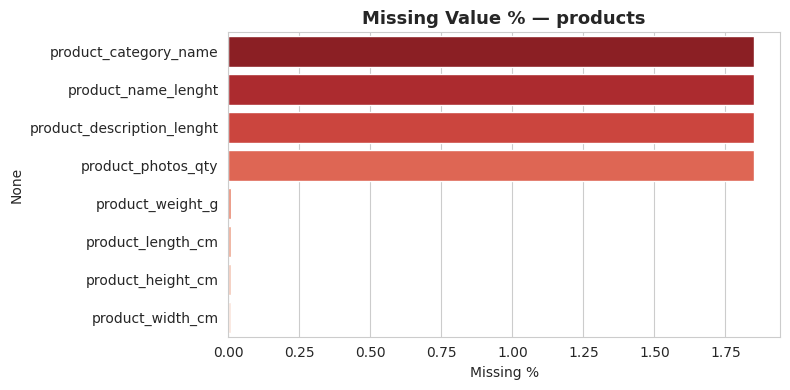

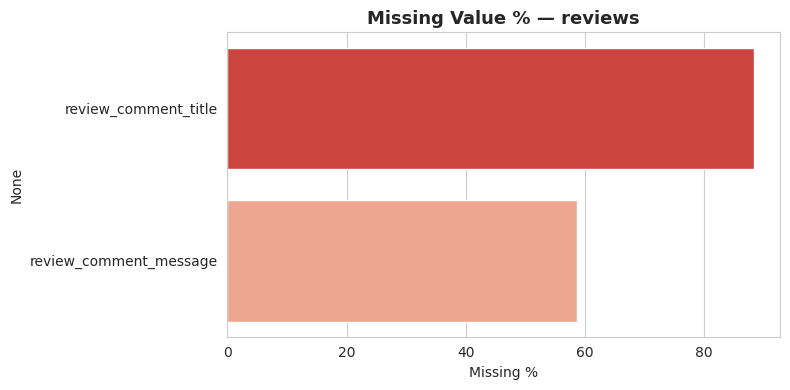

In [14]:
# Visualize missing values across datasets with non-trivial missingness
for name, df in datasets.items():
    if df.empty:
        continue
    rep = missing_value_report(df, name)
    if not rep.empty:
        plt.figure(figsize=(8,4))
        sns.barplot(x=rep['missing_pct'], y=rep.index, palette='Reds_r')
        plt.title(f'Missing Value % — {name}')
        plt.xlabel('Missing %')
        plt.tight_layout()
        plt.show()


In [15]:
print("🧬 DUPLICATE RECORDS")
for name, df in datasets.items():
    if df.empty:
        continue
    dup_count = df.duplicated().sum()
    print(f" - {name}: {dup_count} duplicate rows ({(dup_count/len(df))*100:.3f}%)")


🧬 DUPLICATE RECORDS
 - customers: 0 duplicate rows (0.000%)
 - orders: 0 duplicate rows (0.000%)
 - products: 0 duplicate rows (0.000%)
 - sellers: 0 duplicate rows (0.000%)
 - payments: 0 duplicate rows (0.000%)
 - reviews: 0 duplicate rows (0.000%)
 - items: 0 duplicate rows (0.000%)
 - geolocation: 261831 duplicate rows (26.179%)


In [16]:
print("🔑 UNIQUE VALUE & CARDINALITY ANALYSIS")
for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n--- {name} ---")
    card = pd.DataFrame({
        'unique_values': df.nunique(),
        'cardinality_pct': (df.nunique() / len(df) * 100).round(2)
    }).sort_values('unique_values', ascending=False)
    display(card)


🔑 UNIQUE VALUE & CARDINALITY ANALYSIS

--- customers ---


,unique_values,cardinality_pct
customer_id,99441,100.00
customer_unique_id,96096,96.64
customer_zip_code_prefix,14994,15.08
customer_city,4119,4.14
customer_state,27,0.03



--- orders ---


,unique_values,cardinality_pct
order_id,99441,100.00
customer_id,99441,100.00
order_purchase_timestamp,98875,99.43
order_delivered_customer_date,95664,96.20
order_approved_at,90733,91.24
order_delivered_carrier_date,81018,81.47
order_estimated_delivery_date,459,0.46
order_status,8,0.01



--- products ---


...

,unique_values,cardinality_pct
order_id,98673,99.44
review_id,98410,99.18
review_answer_timestamp,98248,99.02
review_comment_message,36159,36.44
review_comment_title,4527,4.56
review_creation_date,636,0.64
review_score,5,0.01



--- items ---


,unique_values,cardinality_pct
order_id,98666,87.59
shipping_limit_date,93318,82.84
product_id,32951,29.25
freight_value,6999,6.21
price,5968,5.30
seller_id,3095,2.75
order_item_id,21,0.02



--- geolocation ---


,unique_values,cardinality_pct
geolocation_lng,717613,71.75
geolocation_lat,717360,71.72
geolocation_zip_code_prefix,19015,1.90
geolocation_city,8011,0.80
geolocation_state,27,0.00


## 6. Statistical Analysis

In [17]:
print("📊 NUMERICAL STATISTICAL SUMMARY (describe)")
for name, df in datasets.items():
    if df.empty:
        continue
    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] == 0:
        continue
    print(f"\n--- {name} ---")
    display(num_df.describe().T)


📊 NUMERICAL STATISTICAL SUMMARY (describe)

--- customers ---


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,"99,441.00","35,137.47","29,797.94","1,003.00","11,347.00","24,416.00","58,900.00","99,990.00"



--- products ---


,count,mean,std,min,25%,50%,75%,max
product_name_lenght,"32,341.00",48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,"32,341.00",771.50,635.12,4.00,339.00,595.00,972.00,"3,992.00"
product_photos_qty,"32,341.00",2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,"32,949.00","2,276.47","4,282.04",0.00,300.00,700.00,"1,900.00","40,425.00"
product_length_cm,"32,949.00",30.82,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,"32,949.00",16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,"32,949.00",23.20,12.08,6.00,15.00,20.00,30.00,118.00



--- sellers ---


...

,count,mean,std,min,25%,50%,75%,max
review_score,"99,224.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00



--- items ---


,count,mean,std,min,25%,50%,75%,max
order_item_id,"112,650.00",1.20,0.71,1.00,1.00,1.00,1.00,21.00
price,"112,650.00",120.65,183.63,0.85,39.90,74.99,134.90,"6,735.00"
freight_value,"112,650.00",19.99,15.81,0.00,13.08,16.26,21.15,409.68



--- geolocation ---


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,"1,000,163.00","36,574.17","30,549.34","1,001.00","11,075.00","26,530.00","63,504.00","99,990.00"
geolocation_lat,"1,000,163.00",-21.18,5.72,-36.61,-23.60,-22.92,-19.98,45.07
geolocation_lng,"1,000,163.00",-46.39,4.27,-101.47,-48.57,-46.64,-43.77,121.11


In [18]:
print("📐 MEAN / MEDIAN / STD / QUARTILES (per numeric dataset)")
for name, df in datasets.items():
    if df.empty:
        continue
    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] == 0:
        continue
    stats = pd.DataFrame({
        'mean': num_df.mean(),
        'median': num_df.median(),
        'std': num_df.std(),
        'Q1': num_df.quantile(0.25),
        'Q3': num_df.quantile(0.75)
    })
    print(f"\n--- {name} ---")
    display(stats)


📐 MEAN / MEDIAN / STD / QUARTILES (per numeric dataset)

--- customers ---


,mean,median,std,Q1,Q3
customer_zip_code_prefix,"35,137.47","24,416.00","29,797.94","11,347.00","58,900.00"



--- products ---


,mean,median,std,Q1,Q3
product_name_lenght,48.48,51.00,10.25,42.00,57.00
product_description_lenght,771.50,595.00,635.12,339.00,972.00
product_photos_qty,2.19,1.00,1.74,1.00,3.00
product_weight_g,"2,276.47",700.00,"4,282.04",300.00,"1,900.00"
product_length_cm,30.82,25.00,16.91,18.00,38.00
product_height_cm,16.94,13.00,13.64,8.00,21.00
product_width_cm,23.20,20.00,12.08,15.00,30.00



--- sellers ---


...

,mean,median,std,Q1,Q3
review_score,4.09,5.00,1.35,4.00,5.00



--- items ---


,mean,median,std,Q1,Q3
order_item_id,1.20,1.00,0.71,1.00,1.00
price,120.65,74.99,183.63,39.90,134.90
freight_value,19.99,16.26,15.81,13.08,21.15



--- geolocation ---


,mean,median,std,Q1,Q3
geolocation_zip_code_prefix,"36,574.17","26,530.00","30,549.34","11,075.00","63,504.00"
geolocation_lat,-21.18,-22.92,5.72,-23.60,-19.98
geolocation_lng,-46.39,-46.64,4.27,-48.57,-43.77


In [19]:
print("🏷️ CATEGORICAL FREQUENCY ANALYSIS")
for name, df in datasets.items():
    if df.empty:
        continue
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        nunique = df[col].nunique()
        if nunique <= 30:  # skip high-cardinality ID-like columns
            print(f"\n--- {name}.{col} ---")
            freq = df[col].value_counts()
            freq_pct = (df[col].value_counts(normalize=True) * 100).round(2)
            display(pd.DataFrame({'count': freq, 'pct': freq_pct}))


🏷️ CATEGORICAL FREQUENCY ANALYSIS

--- customers.customer_state ---


,count,pct
customer_state,,
SP,41746,41.98
RJ,12852,12.92
MG,11635,11.70
RS,5466,5.50
PR,5045,5.07
SC,3637,3.66
BA,3380,3.40
DF,2140,2.15
ES,2033,2.04



--- orders.order_status ---


,count,pct
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00



--- sellers.seller_state ---


,count,pct
seller_state,,
SP,1849,59.74
PR,349,11.28
MG,244,7.88
SC,190,6.14
RJ,171,5.53
RS,129,4.17
GO,40,1.29
DF,30,0.97
ES,23,0.74



--- payments.payment_type ---


,count,pct
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00



--- geolocation.geolocation_state ---


,count,pct
geolocation_state,,
SP,404268,40.42
MG,126336,12.63
RJ,121169,12.11
RS,61851,6.18
PR,57859,5.78
SC,38328,3.83
BA,36045,3.60
GO,20139,2.01
ES,16748,1.67


## 7. Univariate Analysis

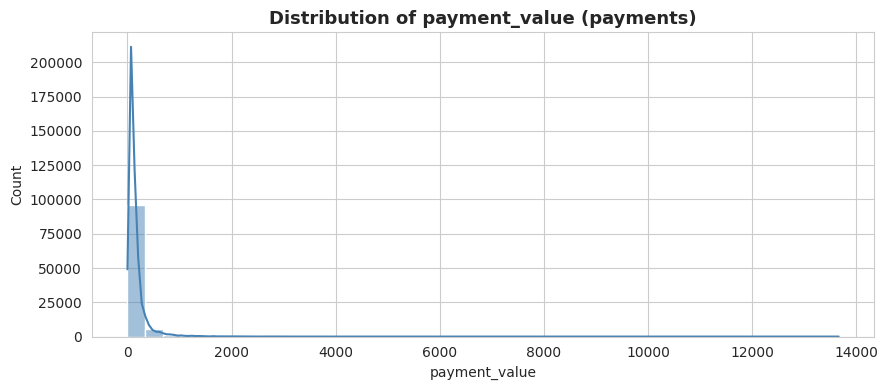

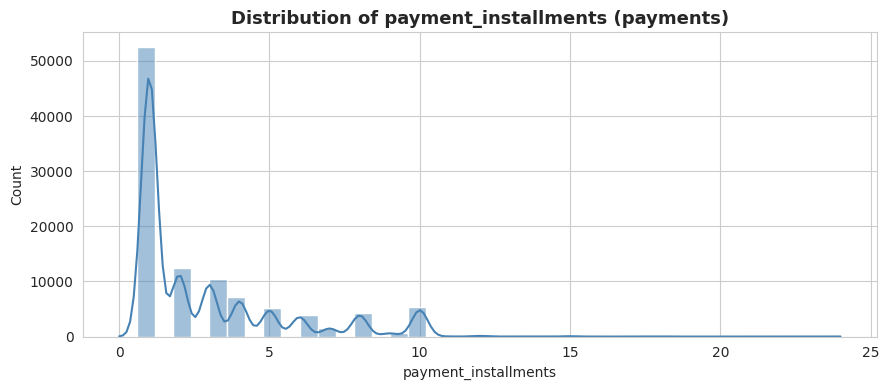

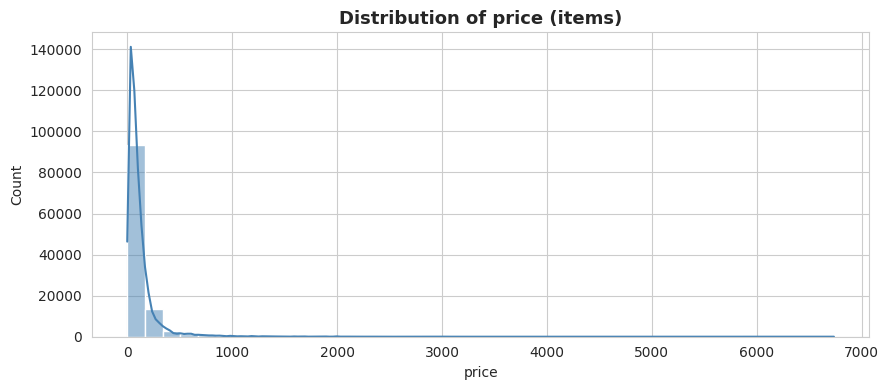

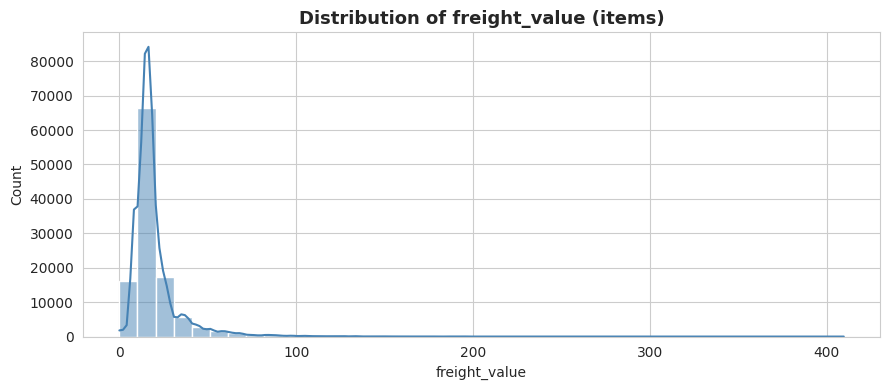

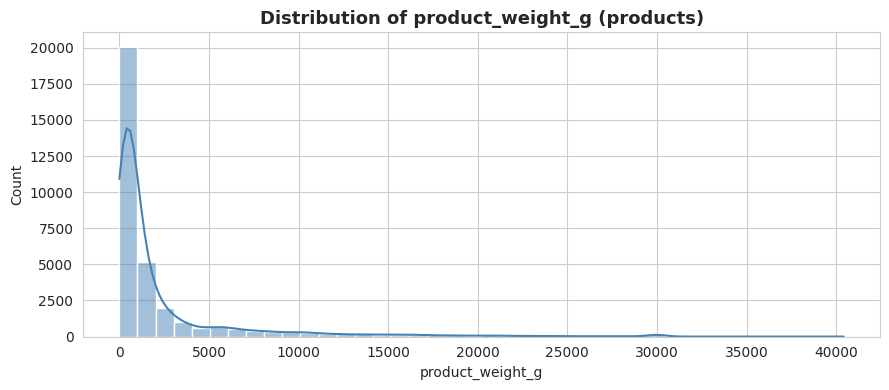

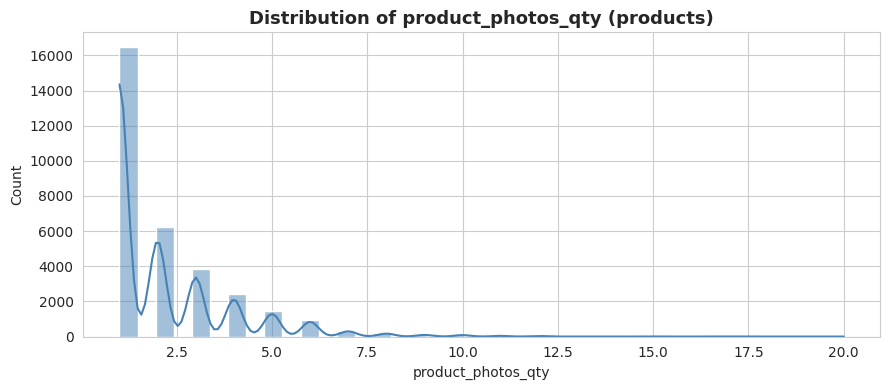

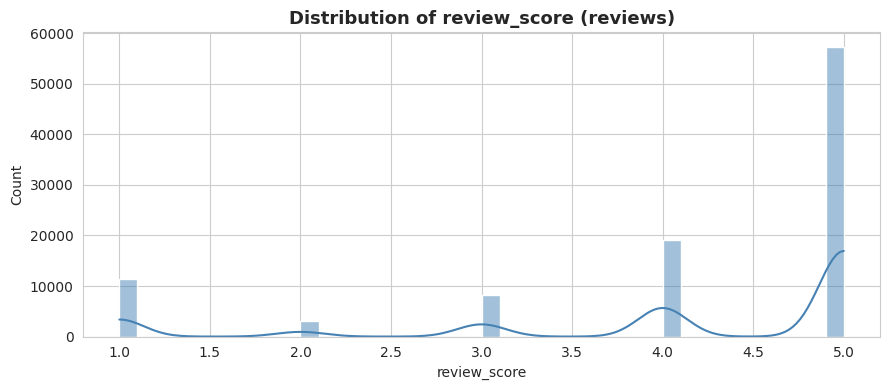

In [20]:
# --- Numerical: Histograms + KDE ---
key_numeric_cols = {
    'payments': ['payment_value', 'payment_installments'],
    'items': ['price', 'freight_value'],
    'products': ['product_weight_g', 'product_photos_qty'],
    'reviews': ['review_score']
}

for name, cols in key_numeric_cols.items():
    df = datasets.get(name)
    if df is None or df.empty:
        continue
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(9,4))
            sns.histplot(df[col].dropna(), kde=True, bins=40, color='steelblue')
            plt.title(f'Distribution of {col} ({name})')
            plt.xlabel(col)
            plt.tight_layout()
            plt.show()


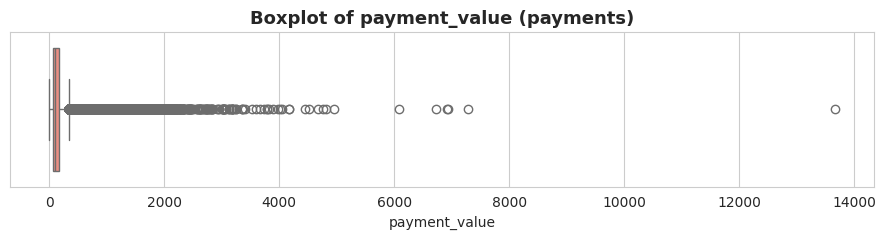

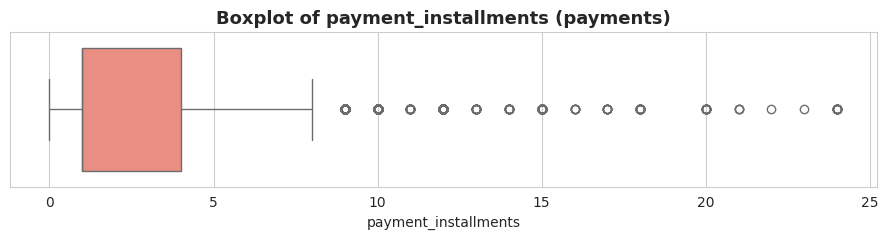

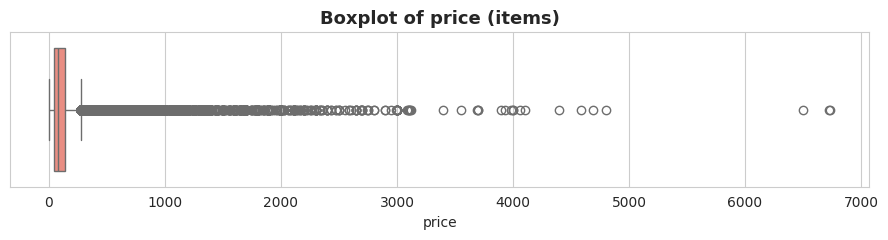

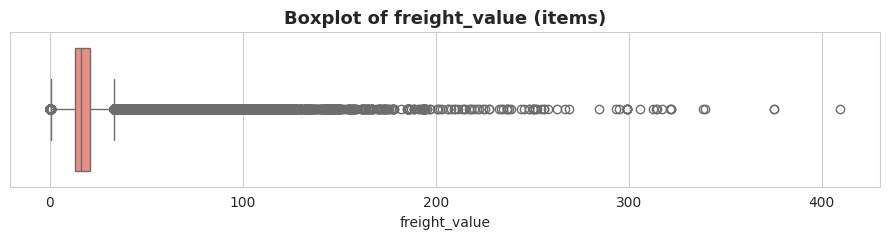

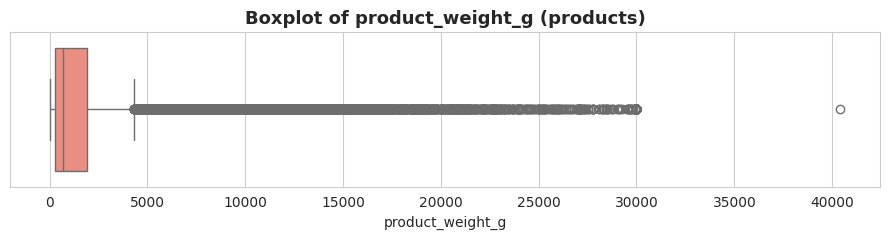

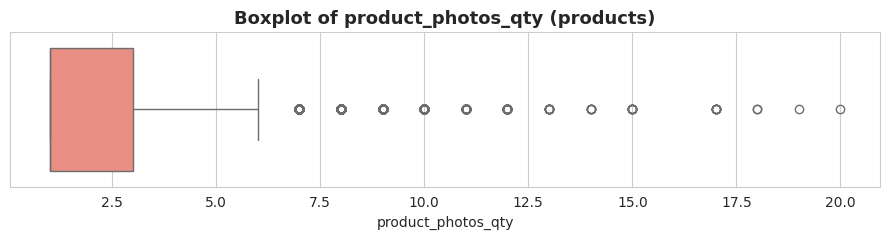

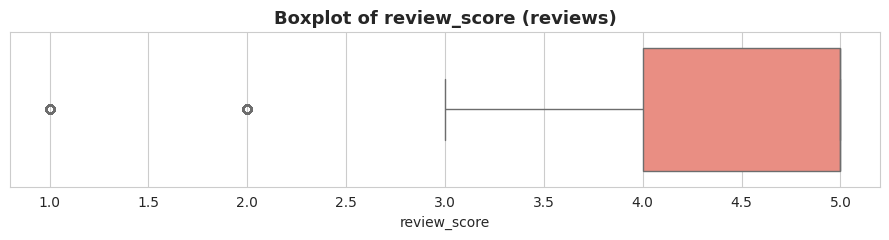

In [21]:
# --- Numerical: Box plots ---
for name, cols in key_numeric_cols.items():
    df = datasets.get(name)
    if df is None or df.empty:
        continue
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(9,2.5))
            sns.boxplot(x=df[col].dropna(), color='salmon')
            plt.title(f'Boxplot of {col} ({name})')
            plt.tight_layout()
            plt.show()


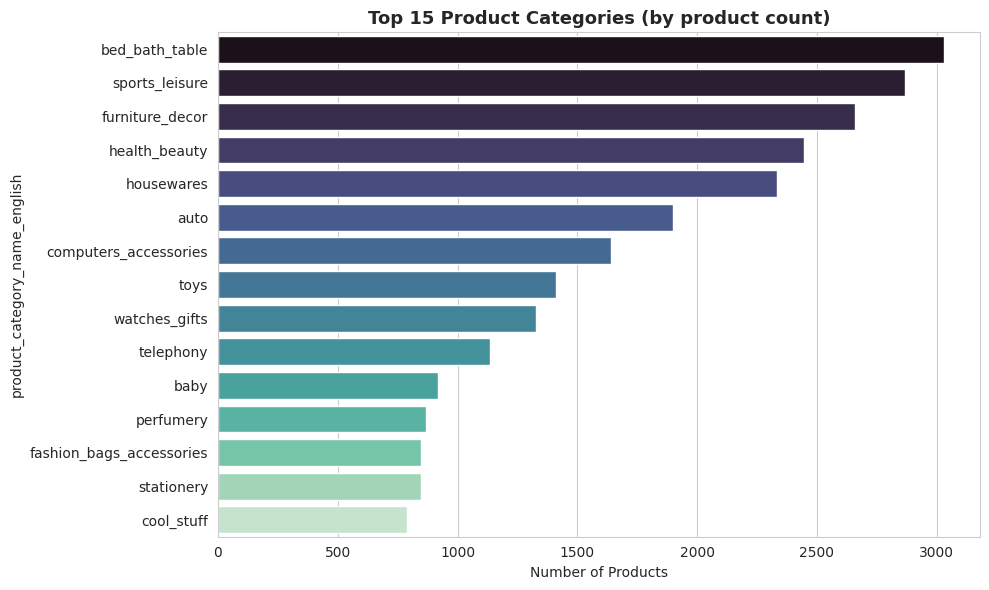

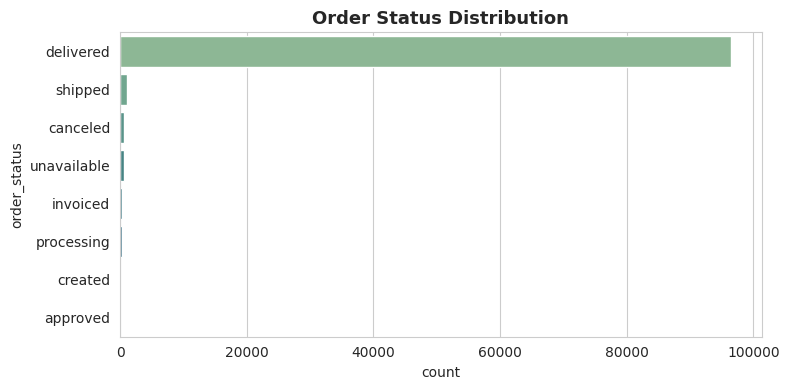

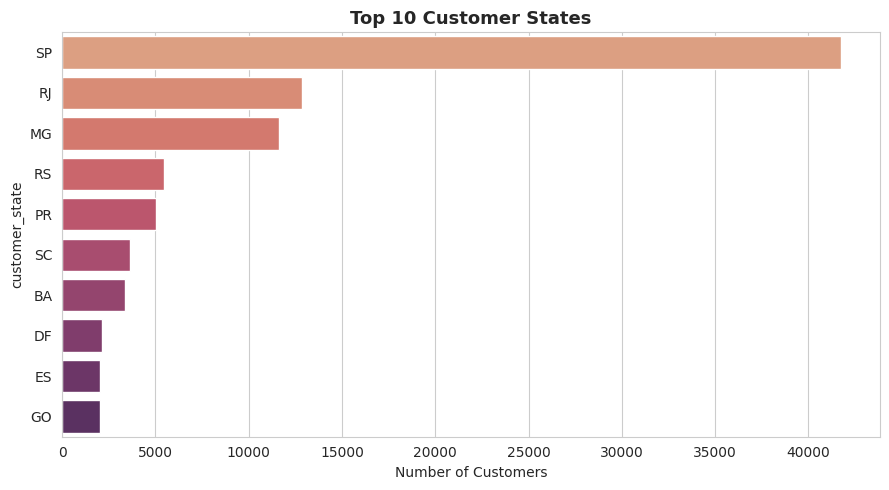

In [22]:
# --- Categorical: Count plots + Top categories ---
if not products.empty:
    cat_col = 'product_category_name_english' if 'product_category_name_english' in products.columns else 'product_category_name'
    if cat_col in products.columns:
        top_categories = products[cat_col].value_counts().head(15)
        plt.figure(figsize=(10,6))
        sns.barplot(x=top_categories.values, y=top_categories.index, palette='mako')
        plt.title('Top 15 Product Categories (by product count)')
        plt.xlabel('Number of Products')
        plt.tight_layout()
        plt.show()

if not orders.empty and 'order_status' in orders.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=orders, y='order_status', order=orders['order_status'].value_counts().index, palette='crest')
    plt.title('Order Status Distribution')
    plt.tight_layout()
    plt.show()

if not customers.empty and 'customer_state' in customers.columns:
    top_states = customers['customer_state'].value_counts().head(10)
    plt.figure(figsize=(9,5))
    sns.barplot(x=top_states.values, y=top_states.index, palette='flare')
    plt.title('Top 10 Customer States')
    plt.xlabel('Number of Customers')
    plt.tight_layout()
    plt.show()


## 8. Bivariate Analysis

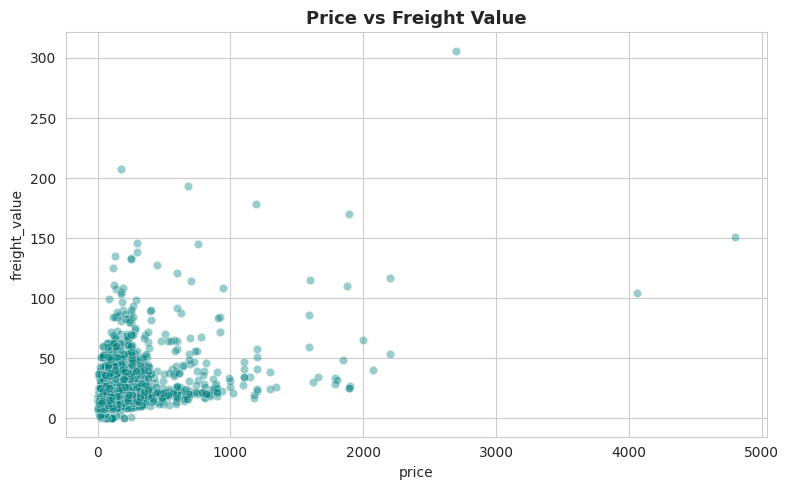

Correlation (price vs freight_value): 0.414


In [23]:
# --- Numerical vs Numerical: Scatter + Correlation ---
if not items.empty and 'price' in items.columns and 'freight_value' in items.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=items.sample(min(5000, len(items)), random_state=42),
                     x='price', y='freight_value', alpha=0.4, color='teal')
    plt.title('Price vs Freight Value')
    plt.tight_layout()
    plt.show()

    corr_val = items[['price', 'freight_value']].corr().iloc[0,1]
    print(f"Correlation (price vs freight_value): {corr_val:.3f}")


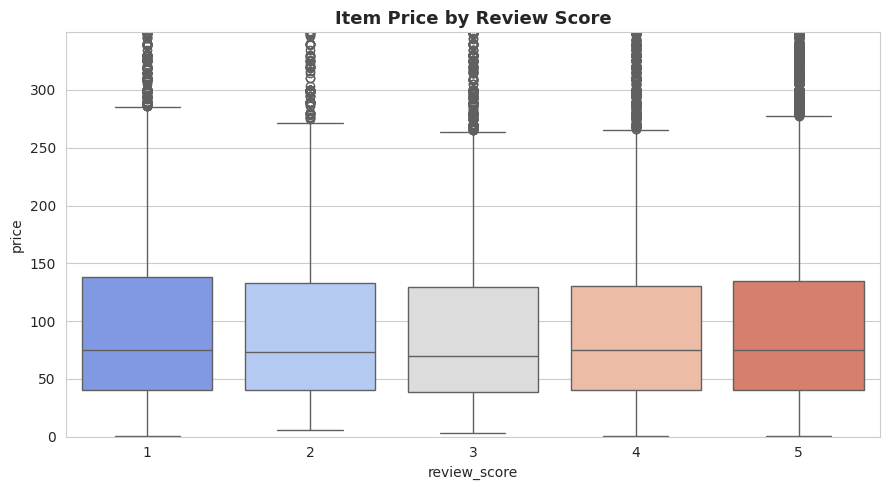

In [24]:
# --- Categorical vs Numerical: Box plots ---
if not reviews.empty and not items.empty and 'order_id' in reviews.columns and 'order_id' in items.columns:
    merged_ri = items.merge(reviews[['order_id','review_score']], on='order_id', how='inner')
    if 'price' in merged_ri.columns:
        plt.figure(figsize=(9,5))
        sns.boxplot(data=merged_ri, x='review_score', y='price', palette='coolwarm')
        plt.title('Item Price by Review Score')
        plt.ylim(0, merged_ri['price'].quantile(0.95))
        plt.tight_layout()
        plt.show()


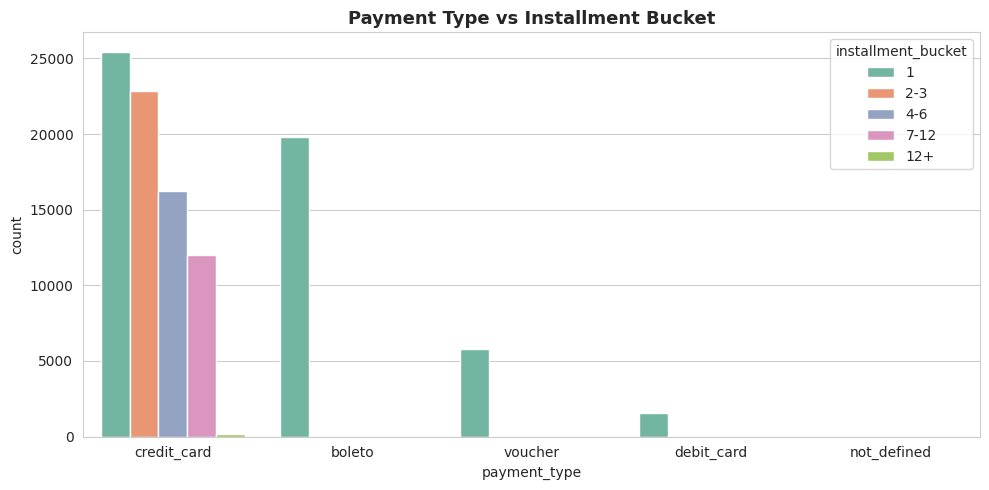

In [25]:
# --- Categorical vs Categorical: Count plot with hue ---
if not payments.empty and 'payment_type' in payments.columns and 'payment_installments' in payments.columns:
    plt.figure(figsize=(10,5))
    top_types = payments['payment_type'].value_counts().head(5).index
    sub = payments[payments['payment_type'].isin(top_types)].copy()
    sub['installment_bucket'] = pd.cut(sub['payment_installments'], bins=[0,1,3,6,12,100],
                                        labels=['1','2-3','4-6','7-12','12+'])
    sns.countplot(data=sub, x='payment_type', hue='installment_bucket', palette='Set2')
    plt.title('Payment Type vs Installment Bucket')
    plt.tight_layout()
    plt.show()


## 9. Multivariate Analysis

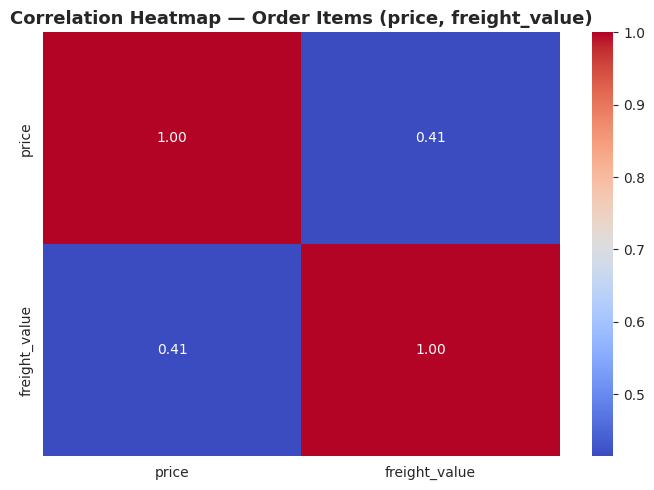

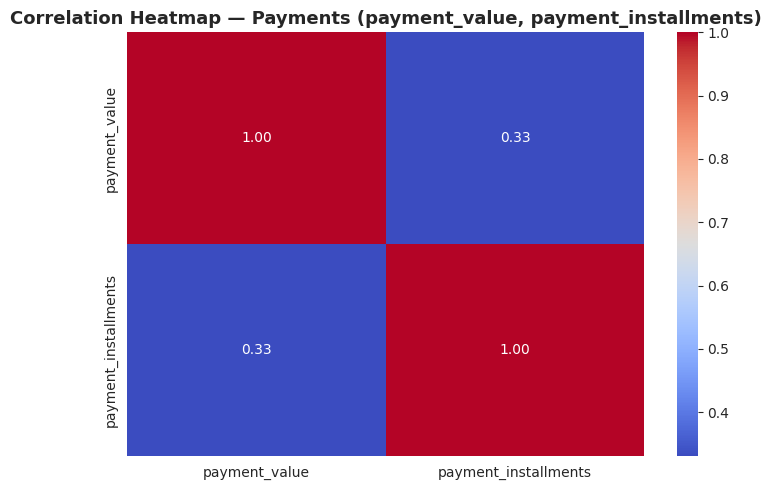

In [26]:
# --- Correlation heatmap (meaningful numeric measures only, ID/sequence columns excluded) ---
if not items.empty and {'price','freight_value'}.issubset(items.columns):
    num_cols = items[['price', 'freight_value']]
    plt.figure(figsize=(7,5))
    sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap \u2014 Order Items (price, freight_value)')
    plt.tight_layout()
    plt.show()

if not payments.empty and {'payment_value','payment_installments'}.issubset(payments.columns):
    num_cols = payments[['payment_value', 'payment_installments']]
    plt.figure(figsize=(7,5))
    sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap \u2014 Payments (payment_value, payment_installments)')
    plt.tight_layout()
    plt.show()

# Note: 'order_item_id' and 'payment_sequential' are sequence/ID columns, not real
# measures, and are deliberately excluded from these correlation heatmaps since
# correlating them with price/freight/payment values would be meaningless.


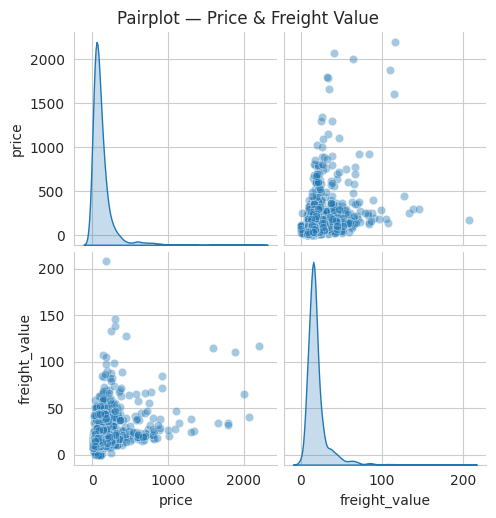

In [27]:
# --- Pair plot (sampled) ---
if not items.empty and {'price','freight_value'}.issubset(items.columns):
    sample_items = items[['price','freight_value']].dropna().sample(min(2000, len(items)), random_state=42)
    sns.pairplot(sample_items, diag_kind='kde', plot_kws={'alpha':0.4})
    plt.suptitle('Pairplot — Price & Freight Value', y=1.02)
    plt.show()


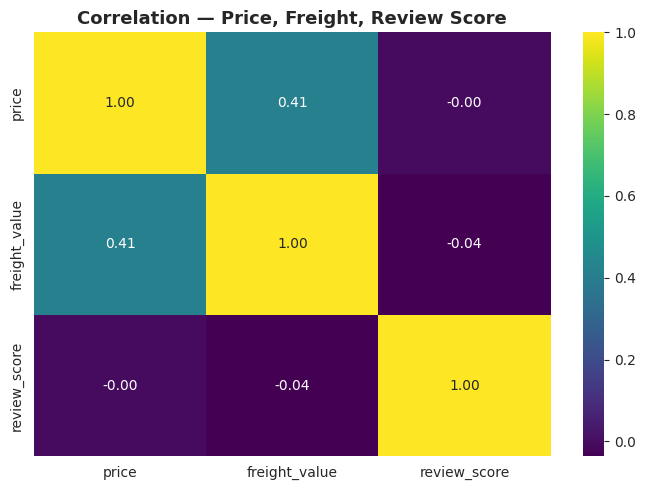

In [28]:
# --- Feature relationships: price + freight + review score together ---
try:
    if 'merged_ri' in globals() and not merged_ri.empty:
        cols = [c for c in ['price','freight_value','review_score'] if c in merged_ri.columns]
        if len(cols) > 1:
            plt.figure(figsize=(7,5))
            sns.heatmap(merged_ri[cols].corr(), annot=True, cmap='viridis', fmt='.2f')
            plt.title('Correlation \u2014 Price, Freight, Review Score')
            plt.tight_layout()
            plt.show()
except NameError:
    pass


## 10. Outlier Detection

In [29]:
def iqr_outlier_report(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    return len(outliers), round(pct, 2), lower, upper

outlier_targets = {
    'items': ['price', 'freight_value'],
    'payments': ['payment_value'],
    'products': ['product_weight_g']
}

outlier_summary = []
for name, cols in outlier_targets.items():
    df = datasets.get(name)
    if df is None or df.empty:
        continue
    for col in cols:
        if col in df.columns:
            count, pct, low, up = iqr_outlier_report(df.dropna(subset=[col]), col)
            outlier_summary.append({'dataset': name, 'column': col, 'outlier_count': count,
                                     'outlier_pct': pct, 'lower_bound': round(low,2), 'upper_bound': round(up,2)})

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


,dataset,column,outlier_count,outlier_pct,lower_bound,upper_bound
0,items,price,8427,7.48,-102.60,277.40
1,items,freight_value,12134,10.77,0.98,33.25
2,payments,payment_value,7981,7.68,-115.78,344.41
3,products,product_weight_g,4551,13.81,"-2,100.00","4,300.00"


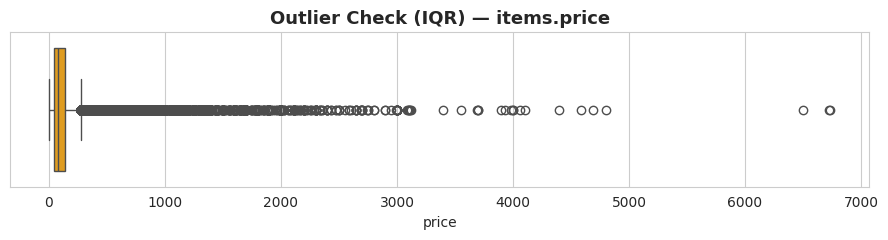

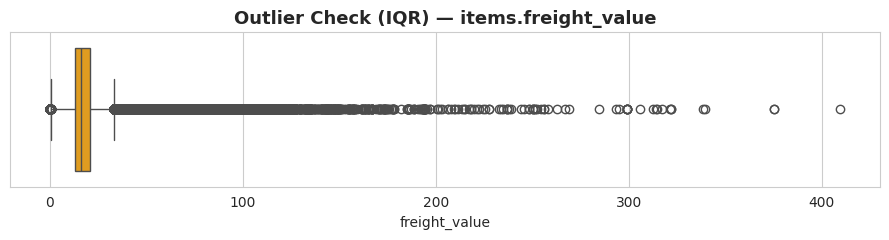

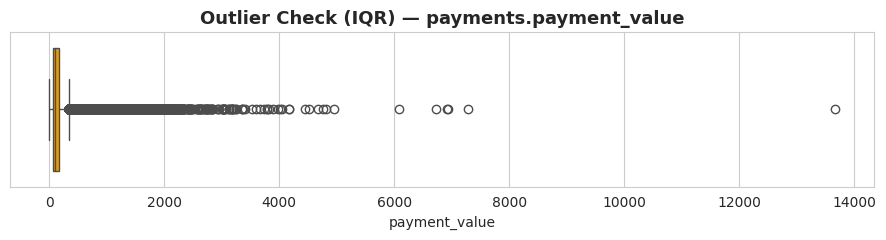

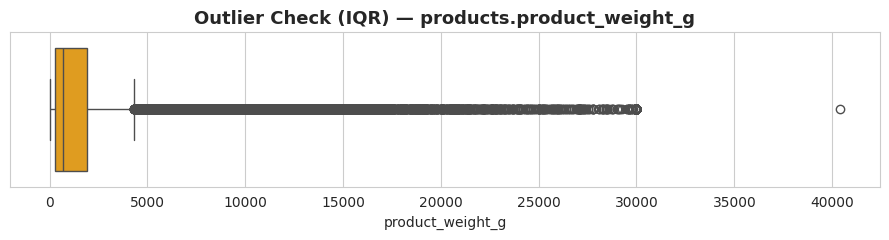

In [30]:
for name, cols in outlier_targets.items():
    df = datasets.get(name)
    if df is None or df.empty:
        continue
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(9,2.5))
            sns.boxplot(x=df[col].dropna(), color='orange')
            plt.title(f'Outlier Check (IQR) — {name}.{col}')
            plt.tight_layout()
            plt.show()


## 11. Date-Time Analysis

In [31]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']

if not orders.empty:
    for col in date_cols:
        if col in orders.columns:
            orders[col] = pd.to_datetime(orders[col], errors='coerce')
    print("✅ Order date columns converted to datetime.")


✅ Order date columns converted to datetime.


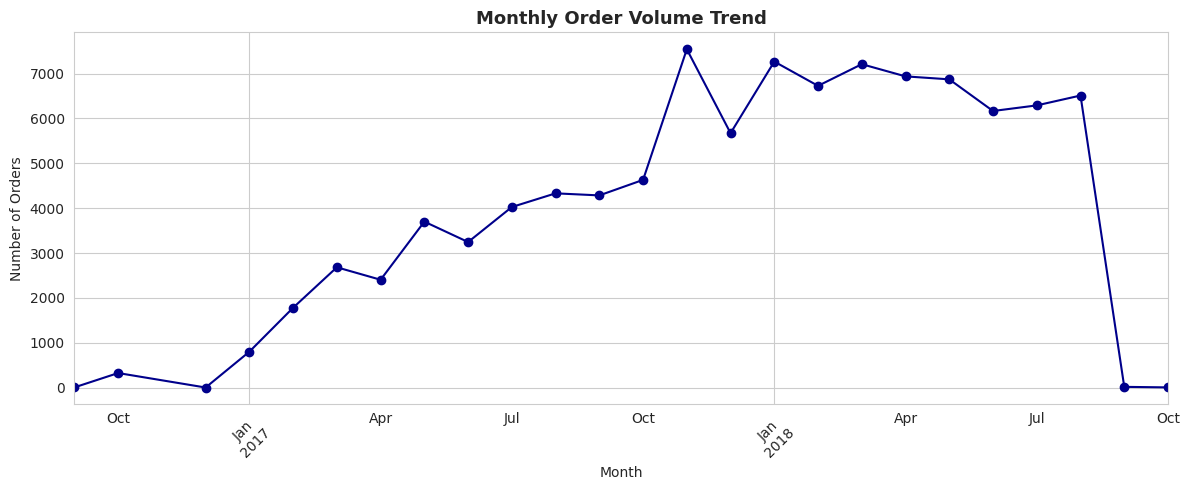

In [32]:
# --- Purchase trends over time ---
if not orders.empty and 'order_purchase_timestamp' in orders.columns:
    orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
    monthly_orders = orders.groupby('purchase_month').size()

    plt.figure(figsize=(12,5))
    monthly_orders.plot(kind='line', marker='o', color='darkblue')
    plt.title('Monthly Order Volume Trend')
    plt.xlabel('Month')
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


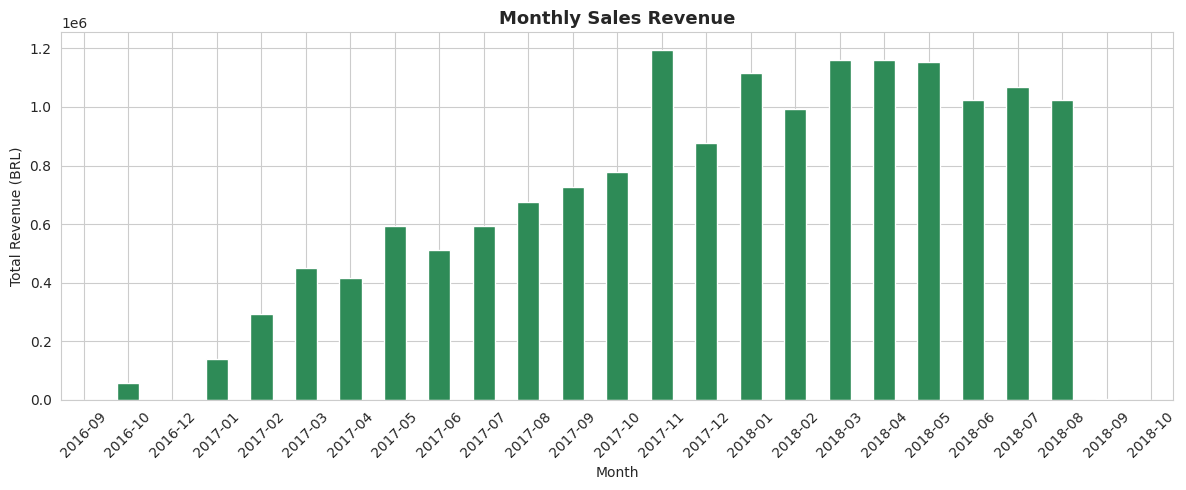

In [33]:
# --- Monthly sales (requires payments merged with orders) ---
if not orders.empty and not payments.empty and 'order_id' in orders.columns:
    sales_df = orders[['order_id','order_purchase_timestamp']].merge(
        payments[['order_id','payment_value']], on='order_id', how='inner')
    sales_df['purchase_month'] = sales_df['order_purchase_timestamp'].dt.to_period('M')
    monthly_sales = sales_df.groupby('purchase_month')['payment_value'].sum()

    plt.figure(figsize=(12,5))
    monthly_sales.plot(kind='bar', color='seagreen')
    plt.title('Monthly Sales Revenue')
    plt.xlabel('Month')
    plt.ylabel('Total Revenue (BRL)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


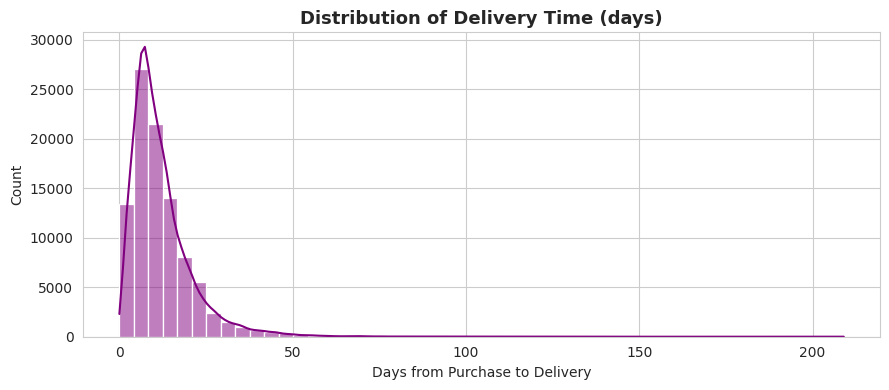

On-time or early delivery rate (delivered orders only): 93.22%
Average delivery time (delivered orders only): 12.1 days
Average delay vs estimate (delivered orders only): -11.9 days


In [34]:
# --- Delivery time analysis ---
if not orders.empty and {'order_delivered_customer_date','order_purchase_timestamp'}.issubset(orders.columns):
    orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
    orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

    plt.figure(figsize=(9,4))
    sns.histplot(orders['delivery_time_days'].dropna(), bins=50, kde=True, color='purple')
    plt.title('Distribution of Delivery Time (days)')
    plt.xlabel('Days from Purchase to Delivery')
    plt.tight_layout()
    plt.show()

    # IMPORTANT: on-time % must be computed only over DELIVERED orders.
    # delivery_delay_days is NaN for non-delivered orders, and NaN <= 0 evaluates
    # to False in pandas rather than being excluded, which would silently inflate
    # the 'late' count if we didn't filter first.
    delivered_only = orders[orders['order_status'] == 'delivered']
    on_time_pct = (delivered_only['delivery_delay_days'] <= 0).mean() * 100
    print(f"On-time or early delivery rate (delivered orders only): {on_time_pct:.2f}%")
    print(f"Average delivery time (delivered orders only): {delivered_only['delivery_time_days'].mean():.1f} days")
    print(f"Average delay vs estimate (delivered orders only): {delivered_only['delivery_delay_days'].mean():.1f} days")


## 12. Business Insights

### 👥 Customer: Customer Distribution

Top 5 states by customer count:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64


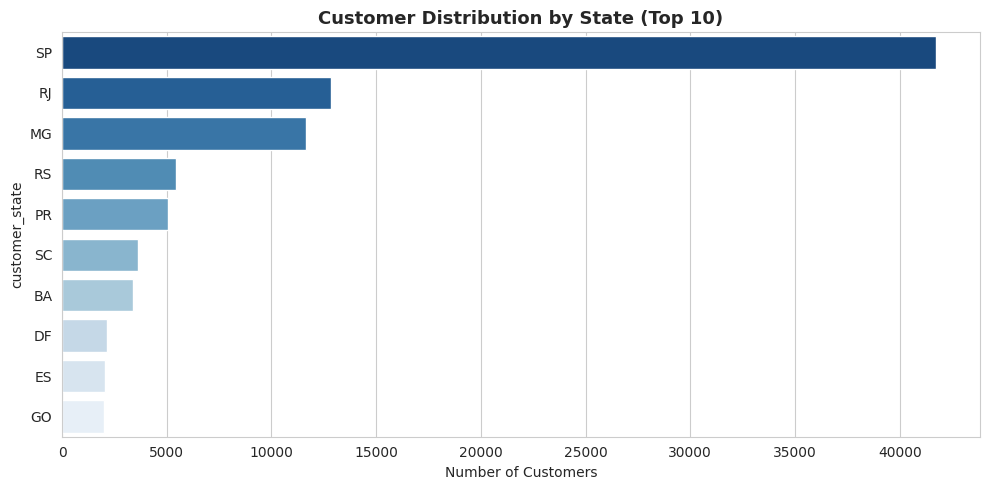

In [35]:
if not customers.empty and 'customer_state' in customers.columns:
    state_dist = customers['customer_state'].value_counts()
    print("Top 5 states by customer count:")
    print(state_dist.head())

    plt.figure(figsize=(10,5))
    sns.barplot(x=state_dist.head(10).values, y=state_dist.head(10).index, palette='Blues_r')
    plt.title('Customer Distribution by State (Top 10)')
    plt.xlabel('Number of Customers')
    plt.tight_layout()
    plt.show()


### 📦 Product: Best Categories

Top 10 categories by revenue:
product_category_name_english
health_beauty           1,258,681.34
watches_gifts           1,205,005.68
bed_bath_table          1,036,988.68
sports_leisure            988,048.97
computers_accessories     911,954.32
furniture_decor           729,762.49
cool_stuff                635,290.85
housewares                632,248.66
auto                      592,720.11
garden_tools              485,256.46
Name: price, dtype: float64


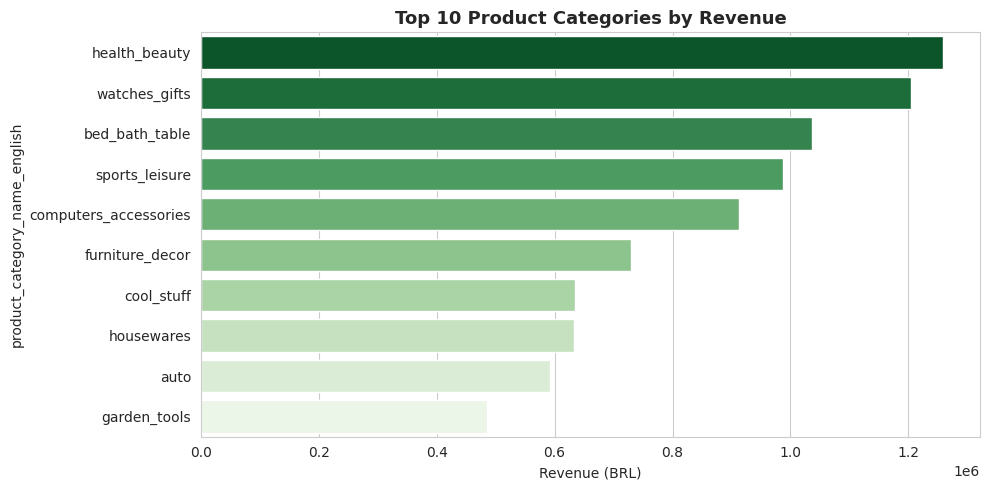

In [36]:
if not products.empty and not items.empty and 'order_id' in items.columns:
    cat_col = 'product_category_name_english' if 'product_category_name_english' in products.columns else 'product_category_name'
    prod_items = items.merge(products[['product_id', cat_col]], on='product_id', how='left')
    revenue_by_cat = prod_items.groupby(cat_col)['price'].sum().sort_values(ascending=False).head(10)

    print("Top 10 categories by revenue:")
    print(revenue_by_cat)

    plt.figure(figsize=(10,5))
    sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, palette='Greens_r')
    plt.title('Top 10 Product Categories by Revenue')
    plt.xlabel('Revenue (BRL)')
    plt.tight_layout()
    plt.show()


### 🏪 Seller: Seller Performance

Top 10 sellers by total sales:


,total_sales,total_orders,avg_price
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,"229,472.63",1132,198.51
53243585a1d6dc2643021fd1853d8905,"222,776.05",358,543.36
4a3ca9315b744ce9f8e9374361493884,"200,472.92",1806,100.89
fa1c13f2614d7b5c4749cbc52fecda94,"194,042.03",585,331.13
7c67e1448b00f6e969d365cea6b010ab,"187,923.89",982,137.77
7e93a43ef30c4f03f38b393420bc753a,"176,431.87",336,518.92
da8622b14eb17ae2831f4ac5b9dab84a,"160,236.57",1314,103.31
7a67c85e85bb2ce8582c35f2203ad736,"141,745.53",1160,121.05
1025f0e2d44d7041d6cf58b6550e0bfa,"138,968.55",915,97.32


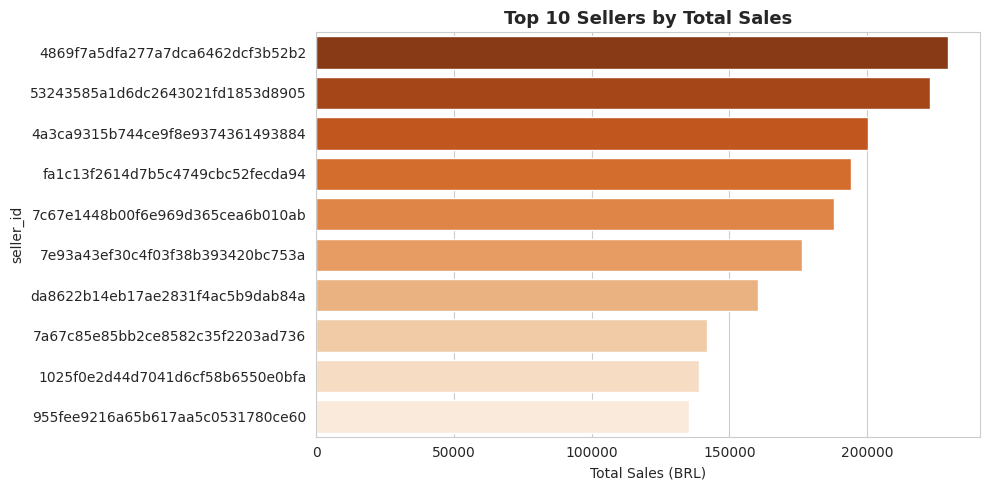

In [37]:
if not items.empty and 'seller_id' in items.columns:
    seller_perf = items.groupby('seller_id').agg(
        total_sales=('price','sum'),
        total_orders=('order_id','nunique'),
        avg_price=('price','mean')
    ).sort_values('total_sales', ascending=False)

    print("Top 10 sellers by total sales:")
    display(seller_perf.head(10))

    plt.figure(figsize=(10,5))
    sns.barplot(x=seller_perf.head(10)['total_sales'], y=seller_perf.head(10).index, palette='Oranges_r')
    plt.title('Top 10 Sellers by Total Sales')
    plt.xlabel('Total Sales (BRL)')
    plt.tight_layout()
    plt.show()


### 💰 Order: Revenue Patterns

Revenue by payment type:
payment_type
credit_card   12,542,084.19
boleto         2,869,361.27
voucher          379,436.87
debit_card       217,989.79
not_defined            0.00
Name: payment_value, dtype: float64


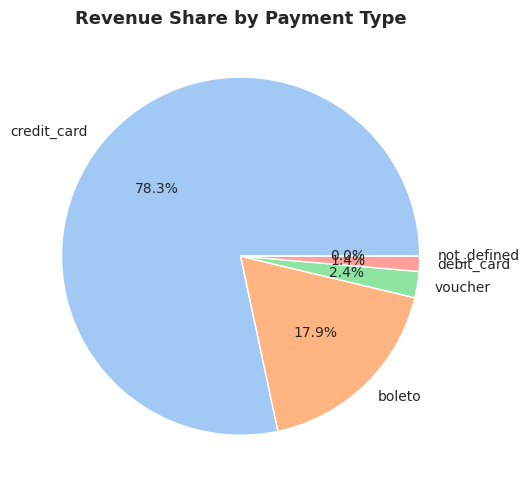

In [38]:
if not payments.empty and 'payment_type' in payments.columns:
    revenue_by_payment = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
    print("Revenue by payment type:")
    print(revenue_by_payment)

    plt.figure(figsize=(8,5))
    plt.pie(revenue_by_payment.values, labels=revenue_by_payment.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
    plt.title('Revenue Share by Payment Type')
    plt.tight_layout()
    plt.show()


## 13. Feature Engineering Preparation

In [39]:
# --- Delivery time & order value features ---
feature_df = orders.copy() if not orders.empty else pd.DataFrame()

if not feature_df.empty:
    if {'order_delivered_customer_date','order_purchase_timestamp'}.issubset(feature_df.columns):
        feature_df['delivery_time_days'] = (feature_df['order_delivered_customer_date'] - feature_df['order_purchase_timestamp']).dt.days
    if {'order_estimated_delivery_date','order_delivered_customer_date'}.issubset(feature_df.columns):
        feature_df['delivery_delay_days'] = (feature_df['order_delivered_customer_date'] - feature_df['order_estimated_delivery_date']).dt.days

    if not payments.empty:
        order_value = payments.groupby('order_id')['payment_value'].sum().rename('order_total_value')
        feature_df = feature_df.merge(order_value, on='order_id', how='left')

    if not items.empty:
        item_count = items.groupby('order_id').size().rename('items_per_order')
        feature_df = feature_df.merge(item_count, on='order_id', how='left')

    if not reviews.empty and 'review_score' in reviews.columns:
        feature_df = feature_df.merge(reviews[['order_id','review_score']], on='order_id', how='left')

    display(feature_df.head())


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_time_days,delivery_delay_days,order_total_value,items_per_order,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.00,-8.00,38.71,1.00,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.00,-6.00,141.46,1.00,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.00,-18.00,179.12,1.00,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.00,-13.00,72.20,1.00,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.00,-10.00,28.62,1.00,5.00


In [40]:
# --- Customer lifetime indicators ---
if not feature_df.empty and not customers.empty and 'customer_id' in feature_df.columns:
    cust_orders = feature_df.merge(customers[['customer_id','customer_unique_id']], on='customer_id', how='left')
    customer_lifetime = cust_orders.groupby('customer_unique_id').agg(
        total_orders=('order_id','nunique'),
        total_spend=('order_total_value','sum'),
        avg_review_score=('review_score','mean')
    ).reset_index()

    customer_lifetime['is_repeat_customer'] = customer_lifetime['total_orders'] > 1
    display(customer_lifetime.head())
    print(f"Repeat customer rate: {customer_lifetime['is_repeat_customer'].mean()*100:.2f}%")


,customer_unique_id,total_orders,total_spend,avg_review_score,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.00,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.00,False
2,0000f46a3911fa3c0805444483337064,1,86.22,3.00,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.00,False
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.00,False


Repeat customer rate: 3.12%


In [41]:
# --- Review score features ---
if not reviews.empty and 'review_score' in reviews.columns:
    reviews['is_positive_review'] = reviews['review_score'] >= 4
    reviews['is_negative_review'] = reviews['review_score'] <= 2
    if 'review_comment_message' in reviews.columns:
        reviews['has_comment'] = reviews['review_comment_message'].notnull()

    print("Review score feature summary:")
    print(reviews[['is_positive_review','is_negative_review']].mean() * 100)


Review score feature summary:
is_positive_review   77.07
is_negative_review   14.69
dtype: float64


In [42]:
print("✅ Feature engineering candidate columns prepared:")
candidate_features = [
    'delivery_time_days', 'delivery_delay_days', 'order_total_value',
    'items_per_order', 'review_score', 'is_positive_review', 'is_negative_review',
    'total_orders (customer)', 'total_spend (customer)', 'is_repeat_customer'
]
for f in candidate_features:
    print(" -", f)


✅ Feature engineering candidate columns prepared:
 - delivery_time_days
 - delivery_delay_days
 - order_total_value
 - items_per_order
 - review_score
 - is_positive_review
 - is_negative_review
 - total_orders (customer)
 - total_spend (customer)
 - is_repeat_customer


## 14. Final EDA Summary

In [43]:
print("="*70)
print("IMPORTANT FINDINGS")
print("="*70)

findings = []

if not orders.empty and 'delivery_time_days' in orders.columns:
    delivered_only = orders[orders['order_status'] == 'delivered']
    findings.append(f"Average delivery time (delivered orders): {delivered_only['delivery_time_days'].mean():.1f} days")
if not orders.empty and 'delivery_delay_days' in orders.columns:
    delivered_only = orders[orders['order_status'] == 'delivered']
    late_pct = (delivered_only['delivery_delay_days'] > 0).mean() * 100
    findings.append(f"Late delivery rate, delivered orders only (vs estimate): {late_pct:.2f}%")
if not reviews.empty and 'review_score' in reviews.columns:
    findings.append(f"Average review score: {reviews['review_score'].mean():.2f} / 5")
    findings.append(f"Positive review rate (score>=4): {(reviews['review_score']>=4).mean()*100:.2f}%")
if not payments.empty and 'payment_value' in payments.columns:
    findings.append(f"Average payment value: R$ {payments['payment_value'].mean():.2f}")
if not customers.empty and 'customer_state' in customers.columns:
    top_state = customers['customer_state'].value_counts().idxmax()
    findings.append(f"Top customer state: {top_state}")

for f in findings:
    print(" -", f)


IMPORTANT FINDINGS
 - Average delivery time (delivered orders): 12.1 days
 - Late delivery rate, delivered orders only (vs estimate): 6.77%
 - Average review score: 4.09 / 5
 - Positive review rate (score>=4): 77.07%
 - Average payment value: R$ 154.10
 - Top customer state: SP


In [44]:
print("="*70)
print("⚠️ DATA ISSUES")
print("="*70)

issues = []
for name, df in datasets.items():
    if df.empty:
        issues.append(f"{name}: dataset not loaded / empty — check DATA_PATH and filename.")
        continue
    rep = missing_value_report(df, name)
    if not rep.empty:
        worst_col = rep['missing_pct'].idxmax()
        issues.append(f"{name}: missing values present, worst column '{worst_col}' "
                       f"({rep.loc[worst_col,'missing_pct']:.1f}% missing)")
    dup = df.duplicated().sum()
    if dup > 0:
        issues.append(f"{name}: {dup} duplicate rows detected.")

if not outlier_df.empty:
    for _, row in outlier_df.iterrows():
        if row['outlier_pct'] > 1:
            issues.append(f"{row['dataset']}.{row['column']}: {row['outlier_pct']}% outliers (IQR method).")

for i in issues:
    print(" •", i)


⚠️ DATA ISSUES
 • orders: missing values present, worst column 'order_delivered_customer_date' (3.0% missing)
 • products: missing values present, worst column 'product_category_name' (1.9% missing)
 • reviews: missing values present, worst column 'review_comment_title' (88.3% missing)
 • geolocation: 261831 duplicate rows detected.
 • items.price: 7.48% outliers (IQR method).
 • items.freight_value: 10.77% outliers (IQR method).
 • payments.payment_value: 7.68% outliers (IQR method).
 • products.product_weight_g: 13.81% outliers (IQR method).


In [45]:
print("="*70)
print("🤖 ML PREPARATION RECOMMENDATIONS")
print("="*70)

recommendations = [
    "Merge orders, items, payments, products, customers and reviews into a single analytical table keyed by order_id for modeling.",
    "Impute or drop rows with missing delivery timestamps depending on the target task (e.g. delivery-delay prediction needs delivered dates).",
    "Cap or log-transform skewed numeric features such as price, freight_value and payment_value before feeding into linear models.",
    "Treat review_score as an ordinal target for satisfaction prediction, or binarize into positive/negative for classification.",
    "Encode categorical features (product_category_name_english, customer_state, payment_type) with one-hot or target encoding depending on cardinality.",
    "Engineer delivery_time_days, delivery_delay_days, items_per_order and order_total_value as core predictive features.",
    "Use customer_unique_id (not customer_id) to correctly compute repeat-purchase and customer lifetime value features.",
    "Consider geolocation data to engineer customer-seller distance as a feature for delivery time / freight prediction.",
    "Remove or separately flag extreme outliers in price/freight (IQR method) rather than silently dropping them.",
    "Stratify any train/test split by time (purchase_month) to avoid leakage in time-dependent tasks like demand forecasting."
]

for r in recommendations:
    print(" •", r)

print("\n✅ EDA COMPLETE. Notebook ready for feature engineering and modeling.")


🤖 ML PREPARATION RECOMMENDATIONS
 • Merge orders, items, payments, products, customers and reviews into a single analytical table keyed by order_id for modeling.
 • Impute or drop rows with missing delivery timestamps depending on the target task (e.g. delivery-delay prediction needs delivered dates).
 • Cap or log-transform skewed numeric features such as price, freight_value and payment_value before feeding into linear models.
 • Treat review_score as an ordinal target for satisfaction prediction, or binarize into positive/negative for classification.
 • Encode categorical features (product_category_name_english, customer_state, payment_type) with one-hot or target encoding depending on cardinality.
 • Engineer delivery_time_days, delivery_delay_days, items_per_order and order_total_value as core predictive features.
 • Use customer_unique_id (not customer_id) to correctly compute repeat-purchase and customer lifetime value features.
 • Consider geolocation data to engineer customer-